<a href="https://colab.research.google.com/github/Yennybel01/HibernateconCRUD/blob/master/Actividad04_Clustering_Iris_Moons_Circles_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 04 — Clustering Lineal y No Lineal con Métricas de Validación

**Objetivo:** Comprender la naturaleza de modelos de clustering lineales y no lineales, aplicando métricas de validación externa (Adjusted Rand Index, V-Measure) e interna (Silhouette Score, Davies-Bouldin Index, Método del Codo).

**Modelos:** K-Means, DBSCAN, Spectral Clustering
**Datasets:** Iris (real), Moons (sintético), Circles (sintético)

---

**Estructura del notebook:** por cada dataset (Iris, Moons, Circles) se entrena y evalúa **cada modelo por separado** (su propio hiperparámetro, su propio entrenamiento, sus propias métricas y su propia gráfica). Al final de cada caso hay una tabla comparativa de recapitulación. La sección 6 resume, por modelo, su naturaleza lineal/no lineal y sus hiperparámetros críticos.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, make_moons, make_circles
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    adjusted_rand_score,
    v_measure_score,
    silhouette_score,
    davies_bouldin_score
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Funciones auxiliares

- `k_distance_plot`: grafica la distancia al k-ésimo vecino más cercano (ordenada); el "codo" sugiere un buen `eps` para DBSCAN.
- `elbow_method`: entrena K-Means para distintos `k` y grafica la inercia (método del codo).
- `compute_metrics_single`: calcula las métricas externas (ARI, V-Measure) e internas (Silhouette, Davies-Bouldin) de **un solo modelo** y las devuelve como una tabla de una fila.
- `plot_two_panel`: grafica etiquetas reales vs. las predichas por **un solo modelo**.
- `plot_all_models`: grafica etiquetas reales vs. los 3 modelos juntos (solo para la comparación final de cada caso).

In [ ]:
def k_distance_plot(X, k=5, title=""):
    """
    Grafica la distancia al k-esimo vecino mas cercano, ordenada de menor a mayor.
    El "codo" de esta curva es un buen candidato para el hiperparametro eps de DBSCAN.
    """
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors.fit(X)
    distances, _ = neighbors.kneighbors(X)
    k_distances = np.sort(distances[:, k - 1])

    plt.figure(figsize=(6, 4))
    plt.plot(k_distances)
    plt.xlabel("Puntos ordenados por distancia")
    plt.ylabel(f"Distancia al {k}-esimo vecino mas cercano")
    plt.title(f"Grafica de k-distancias - {title}")
    plt.grid(True)
    plt.show()

    return k_distances


def elbow_method(X, max_k=8, title=""):
    """
    Metodo del codo: entrena K-Means para k=1..max_k y grafica la inercia.
    """
    inertias = []
    K_range = range(1, max_k + 1)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        km.fit(X)
        inertias.append(km.inertia_)

    plt.figure(figsize=(6, 4))
    plt.plot(list(K_range), inertias, "bo-")
    plt.xlabel("Numero de clusters (k)")
    plt.ylabel("Inercia")
    plt.title(f"Metodo del Codo - {title}")
    plt.grid(True)
    plt.show()

    return inertias


def compute_metrics_single(X, y_true, labels, model_name):
    """
    Calcula las metricas de UN solo modelo:
      - EXTERNAS (necesitan las etiquetas reales): ARI, V-Measure
      - INTERNAS (no necesitan las etiquetas reales): Silhouette, Davies-Bouldin

    Si el modelo es DBSCAN y genero puntos de ruido (-1), estos se excluyen
    del calculo de las metricas internas.
    Devuelve un DataFrame de una sola fila (facil de imprimir o concatenar despues).
    """
    ari = adjusted_rand_score(y_true, labels)
    vm = v_measure_score(y_true, labels)

    unique_labels = set(labels)
    n_clusters_found = len(unique_labels - {-1})
    n_noise = int(np.sum(labels == -1))

    if n_clusters_found > 1:
        mask = labels != -1
        sil = silhouette_score(X[mask], labels[mask])
        dbi = davies_bouldin_score(X[mask], labels[mask])
    else:
        sil, dbi = np.nan, np.nan

    return pd.DataFrame([{
        "Modelo": model_name,
        "ARI": round(ari, 4),
        "V-Measure": round(vm, 4),
        "Silhouette": round(sil, 4) if not np.isnan(sil) else np.nan,
        "Davies-Bouldin": round(dbi, 4) if not np.isnan(dbi) else np.nan,
        "Clusters_encontrados": n_clusters_found,
        "Puntos_ruido": n_noise
    }])


def plot_two_panel(X_2d, y_true, labels, model_name, dataset_name):
    """
    Grafica en 2D: etiquetas reales (izquierda) vs. las predichas por UN modelo (derecha).
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap="viridis",
                     s=30, edgecolor="k", linewidth=0.3)
    axes[0].set_title(f"{dataset_name} - Etiquetas reales")
    axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="viridis",
                     s=30, edgecolor="k", linewidth=0.3)
    axes[1].set_title(f"{dataset_name} - {model_name}")
    plt.tight_layout()
    plt.savefig(f"{dataset_name}_{model_name}.png", dpi=120, bbox_inches="tight")
    plt.show()


def plot_all_models(X_2d, y_true, models_labels, dataset_name):
    """
    Grafica en 2D: etiquetas reales vs. predicciones de los 3 modelos juntos.
    Se usa solo en la comparacion final de cada caso.
    """
    n_plots = len(models_labels) + 1
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4.5))
    axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap="viridis",
                     s=30, edgecolor="k", linewidth=0.3)
    axes[0].set_title(f"{dataset_name} - Etiquetas reales")
    for ax, (name, labels) in zip(axes[1:], models_labels.items()):
        ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="viridis",
                   s=30, edgecolor="k", linewidth=0.3)
        ax.set_title(f"{dataset_name} - {name}")
    plt.tight_layout()
    plt.savefig(f"clusters_{dataset_name}_comparacion.png", dpi=120, bbox_inches="tight")
    plt.show()

## 2. Caso: Dataset Iris

El dataset Iris contiene 150 muestras de 3 especies de flores (*setosa*, *versicolor*, *virginica*), descritas por 4 características numéricas. *Setosa* es linealmente separable del resto, mientras que *versicolor* y *virginica* presentan cierto solapamiento. Como tiene 4 dimensiones, usamos PCA solo para poder **graficar** en 2D (los modelos se entrenan con las 4 dimensiones originales, no con la proyección PCA).

In [ ]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

pca_iris = PCA(n_components=2, random_state=RANDOM_STATE)
X_iris_2d = pca_iris.fit_transform(X_iris_scaled)

print("Forma de X:", X_iris_scaled.shape)
print("Especies:", list(iris.target_names))
print("Distribucion de clases:")
print(pd.Series(y_iris).value_counts().sort_index())
print(f"Varianza explicada por las 2 componentes (solo para graficar): {pca_iris.explained_variance_ratio_.sum():.2%}")

Forma de X: (150, 4)
Especies: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Distribucion de clases:
0    50
1    50
2    50
Name: count, dtype: int64
Varianza explicada por las 2 componentes (solo para graficar): 95.81%


### 2.1 Modelo K-Means (Iris)

K-Means es un algoritmo **basado en centroides**: asigna cada punto al centroide más cercano (distancia euclidiana) y recalcula los centroides iterativamente. Sus fronteras de decisión son hiperplanos, por lo que asume clusters **convexos**. Su hiperparámetro más crítico es `n_clusters`; aquí usamos `n_clusters=3` (conocido por el ground truth) y lo confirmamos con el método del codo.

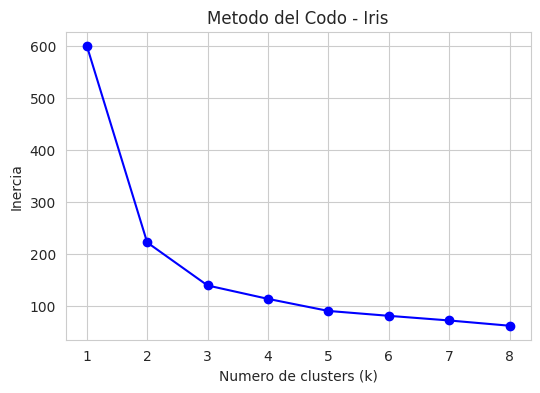

In [ ]:
_ = elbow_method(X_iris_scaled, max_k=8, title="Iris")

In [ ]:
kmeans_iris = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
labels_kmeans_iris = kmeans_iris.fit_predict(X_iris_scaled)

metrics_kmeans_iris = compute_metrics_single(X_iris_scaled, y_iris, labels_kmeans_iris, "K-Means")
metrics_kmeans_iris

,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin,Clusters_encontrados,Puntos_ruido
0,K-Means,0.6201,0.6595,0.4599,0.8336,3,0


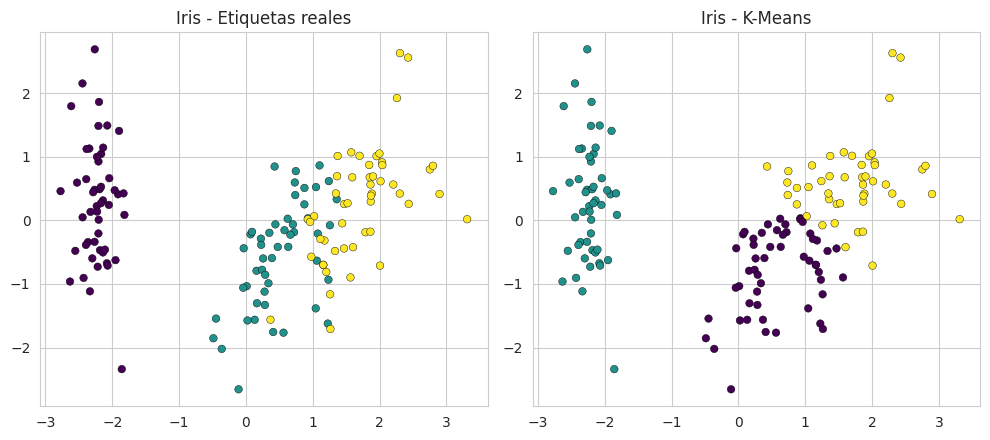

In [ ]:
plot_two_panel(X_iris_2d, y_iris, labels_kmeans_iris, "K-Means", "Iris")

### 2.2 Modelo DBSCAN (Iris)

DBSCAN es un algoritmo **basado en densidad**: agrupa puntos que están suficientemente cerca entre sí (radio `eps`) y que tienen al menos `min_samples` vecinos; los puntos que no cumplen esto se marcan como ruido (etiqueta `-1`). No necesita que indiquemos el número de clusters de antemano. Usamos la gráfica de k-distancias para elegir `eps`.

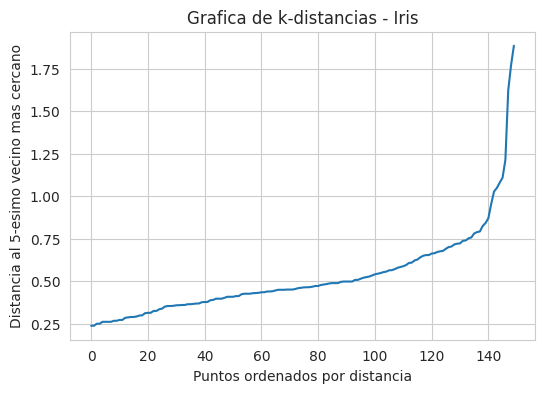

In [ ]:
_ = k_distance_plot(X_iris_scaled, k=5, title="Iris")

In [ ]:
EPS_IRIS = 0.9
MIN_SAMPLES_IRIS = 5

dbscan_iris = DBSCAN(eps=EPS_IRIS, min_samples=MIN_SAMPLES_IRIS)
labels_dbscan_iris = dbscan_iris.fit_predict(X_iris_scaled)

metrics_dbscan_iris = compute_metrics_single(X_iris_scaled, y_iris, labels_dbscan_iris, "DBSCAN")
metrics_dbscan_iris

,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin,Clusters_encontrados,Puntos_ruido
0,DBSCAN,0.5518,0.69,0.5979,0.5688,2,4


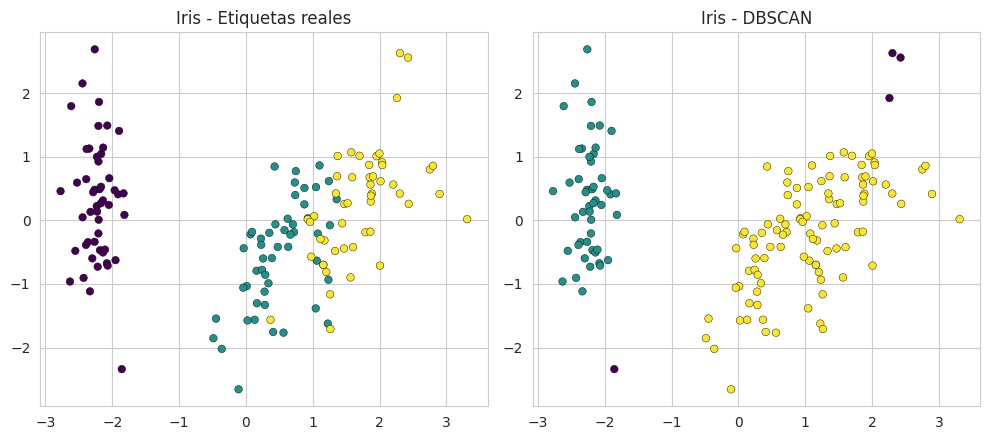

In [ ]:
plot_two_panel(X_iris_2d, y_iris, labels_dbscan_iris, "DBSCAN", "Iris")

### 2.3 Modelo Spectral Clustering (Iris)

Spectral Clustering construye un **grafo de similitud** entre los puntos y agrupa usando los autovectores del Laplaciano de ese grafo, lo que le permite capturar estructuras no convexas. Igual que K-Means, necesita `n_clusters` como hiperparámetro (también lo tomamos del ground truth: `n_clusters=3`), además de `affinity` (aquí `'nearest_neighbors'`).

In [ ]:
spectral_iris = SpectralClustering(n_clusters=3, affinity="nearest_neighbors",
                                    n_neighbors=10, random_state=RANDOM_STATE)
labels_spectral_iris = spectral_iris.fit_predict(X_iris_scaled)

metrics_spectral_iris = compute_metrics_single(X_iris_scaled, y_iris, labels_spectral_iris, "SpectralClustering")
metrics_spectral_iris

,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin,Clusters_encontrados,Puntos_ruido
0,SpectralClustering,0.6465,0.6838,0.4593,0.8224,3,0


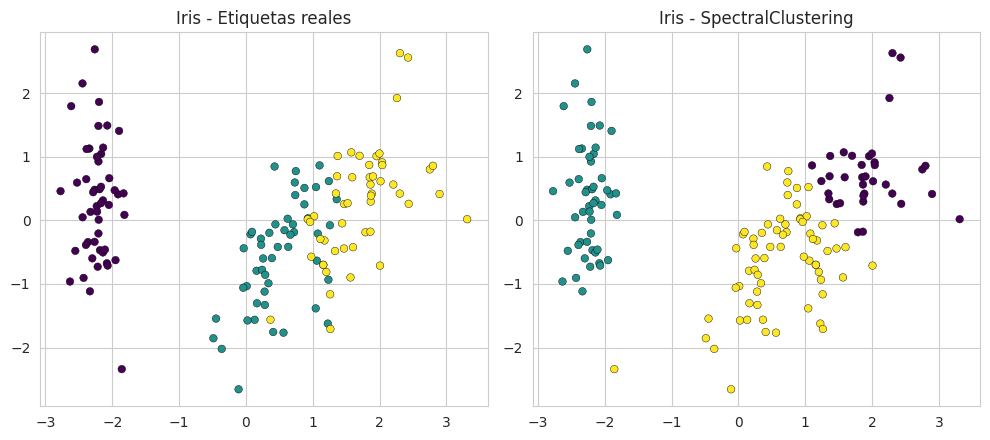

In [ ]:
plot_two_panel(X_iris_2d, y_iris, labels_spectral_iris, "SpectralClustering", "Iris")

### 2.4 Comparación de los 3 modelos en Iris

In [ ]:
comparacion_iris = pd.concat(
    [metrics_kmeans_iris, metrics_dbscan_iris, metrics_spectral_iris],
    ignore_index=True
)
comparacion_iris

,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin,Clusters_encontrados,Puntos_ruido
0,K-Means,0.6201,0.6595,0.4599,0.8336,3,0
1,DBSCAN,0.5518,0.6900,0.5979,0.5688,2,4
2,SpectralClustering,0.6465,0.6838,0.4593,0.8224,3,0


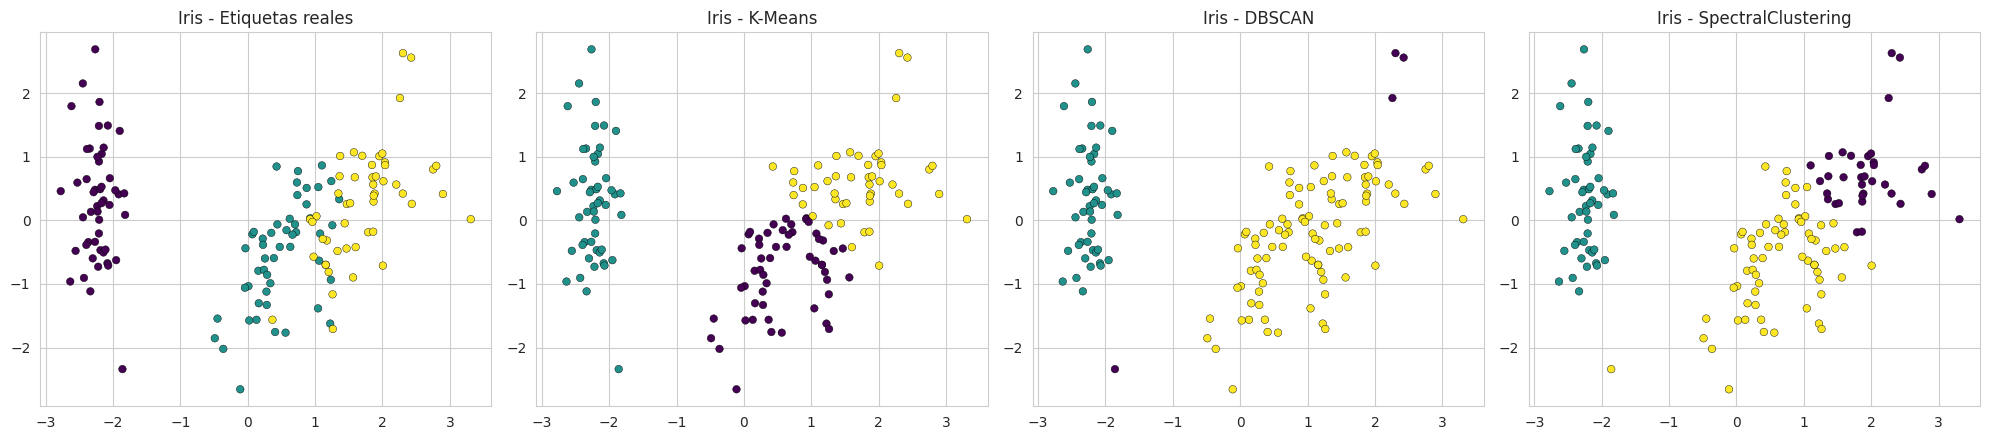

In [ ]:
models_iris = {
    "K-Means": labels_kmeans_iris,
    "DBSCAN": labels_dbscan_iris,
    "SpectralClustering": labels_spectral_iris
}
plot_all_models(X_iris_2d, y_iris, models_iris, "Iris")

## 3. Caso: Dataset Moons

`make_moons` genera dos "medias lunas" entrelazadas. Es un dataset clásico para mostrar los límites de los algoritmos que asumen clusters convexos/esféricos (K-Means), frente a algoritmos que pueden modelar fronteras no lineales (DBSCAN, Spectral Clustering). Como ya tiene 2 dimensiones, no se necesita PCA para graficar.

In [ ]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.07, random_state=RANDOM_STATE)

scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

print("Forma de X:", X_moons_scaled.shape)
print("Distribucion de clases:", pd.Series(y_moons).value_counts().sort_index().to_dict())

Forma de X: (300, 2)
Distribucion de clases: {0: 150, 1: 150}


### 3.1 Modelo K-Means (Moons)

K-Means es un algoritmo **basado en centroides**: asigna cada punto al centroide más cercano (distancia euclidiana) y recalcula los centroides iterativamente. Sus fronteras de decisión son hiperplanos, por lo que asume clusters **convexos**. Su hiperparámetro más crítico es `n_clusters`; aquí usamos `n_clusters=2` (conocido por el ground truth) y lo confirmamos con el método del codo.

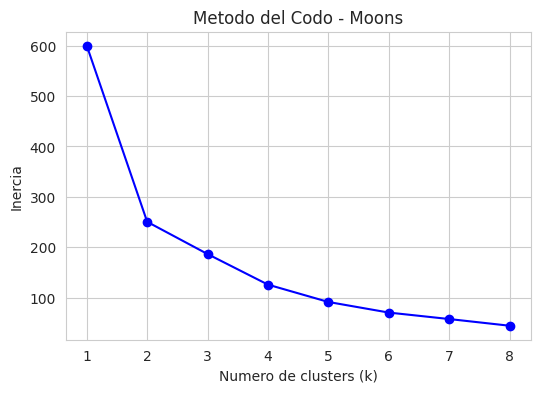

In [ ]:
_ = elbow_method(X_moons_scaled, max_k=8, title="Moons")

In [ ]:
kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels_kmeans_moons = kmeans_moons.fit_predict(X_moons_scaled)

metrics_kmeans_moons = compute_metrics_single(X_moons_scaled, y_moons, labels_kmeans_moons, "K-Means")
metrics_kmeans_moons

,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin,Clusters_encontrados,Puntos_ruido
0,K-Means,0.479,0.3819,0.4945,0.8057,2,0


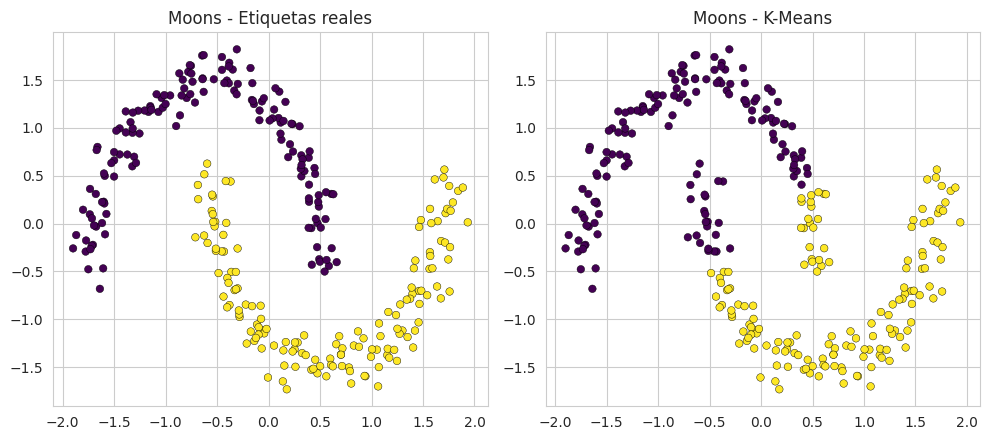

In [ ]:
plot_two_panel(X_moons_scaled, y_moons, labels_kmeans_moons, "K-Means", "Moons")

### 3.2 Modelo DBSCAN (Moons)

DBSCAN es un algoritmo **basado en densidad**: agrupa puntos que están suficientemente cerca entre sí (radio `eps`) y que tienen al menos `min_samples` vecinos; los puntos que no cumplen esto se marcan como ruido (etiqueta `-1`). No necesita que indiquemos el número de clusters de antemano. Usamos la gráfica de k-distancias para elegir `eps`.

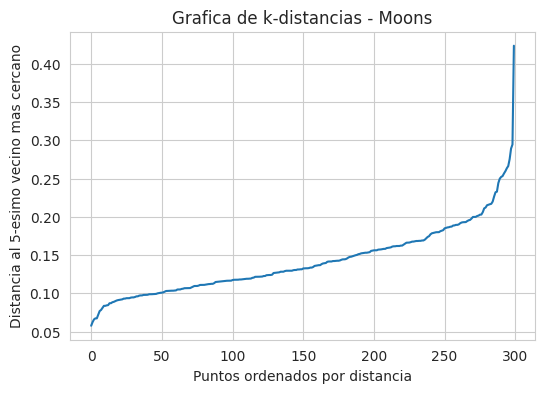

In [ ]:
_ = k_distance_plot(X_moons_scaled, k=5, title="Moons")

In [ ]:
EPS_MOONS = 0.3
MIN_SAMPLES_MOONS = 5

dbscan_moons = DBSCAN(eps=EPS_MOONS, min_samples=MIN_SAMPLES_MOONS)
labels_dbscan_moons = dbscan_moons.fit_predict(X_moons_scaled)

metrics_dbscan_moons = compute_metrics_single(X_moons_scaled, y_moons, labels_dbscan_moons, "DBSCAN")
metrics_dbscan_moons

,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin,Clusters_encontrados,Puntos_ruido
0,DBSCAN,1.0,1.0,0.3824,1.0234,2,0


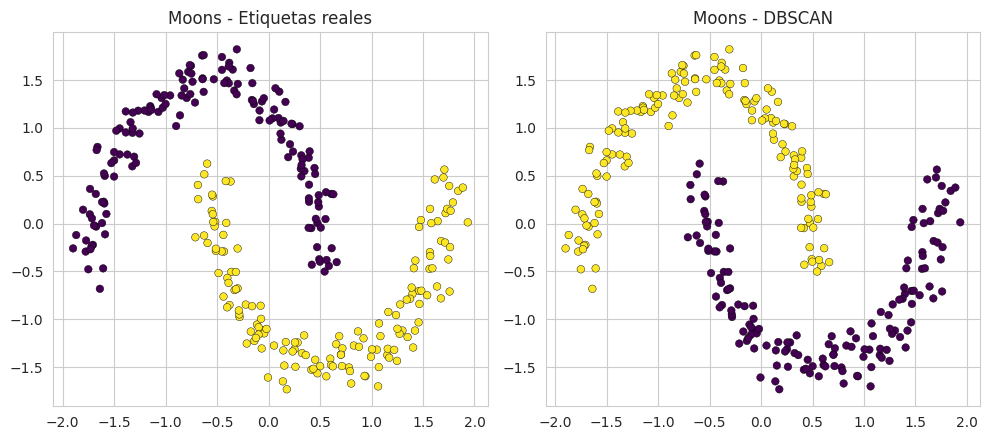

In [ ]:
plot_two_panel(X_moons_scaled, y_moons, labels_dbscan_moons, "DBSCAN", "Moons")

### 3.3 Modelo Spectral Clustering (Moons)

Spectral Clustering construye un **grafo de similitud** entre los puntos y agrupa usando los autovectores del Laplaciano de ese grafo, lo que le permite capturar estructuras no convexas. Igual que K-Means, necesita `n_clusters` como hiperparámetro (también lo tomamos del ground truth: `n_clusters=2`), además de `affinity` (aquí `'nearest_neighbors'`).

In [ ]:
spectral_moons = SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                                    n_neighbors=10, random_state=RANDOM_STATE)
labels_spectral_moons = spectral_moons.fit_predict(X_moons_scaled)

metrics_spectral_moons = compute_metrics_single(X_moons_scaled, y_moons, labels_spectral_moons, "SpectralClustering")
metrics_spectral_moons

,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin,Clusters_encontrados,Puntos_ruido
0,SpectralClustering,1.0,1.0,0.3824,1.0234,2,0


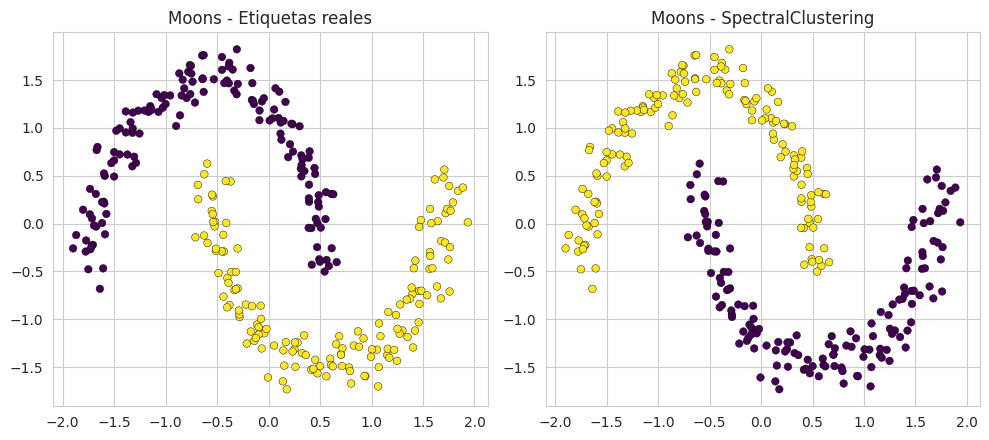

In [ ]:
plot_two_panel(X_moons_scaled, y_moons, labels_spectral_moons, "SpectralClustering", "Moons")

In [ ]:
import pandas as pd

resultados_nn = []
for k in [2, 3, 5, 10, 20, 50]:
    sp = SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                             n_neighbors=k, random_state=RANDOM_STATE)
    labels = sp.fit_predict(X_moons_scaled)
    ari = adjusted_rand_score(y_moons, labels)
    resultados_nn.append({"n_neighbors": k, "ARI": ari})

pd.DataFrame(resultados_nn)

,n_neighbors,ARI
0,2,0.002133
1,3,0.004015
2,5,0.007446
3,10,1.000000
4,20,0.895830
5,50,0.556027


In [ ]:
import numpy as np
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian, connected_components

for k_diag in [3, 5, 7, 10, 15]:
    W = kneighbors_graph(X_moons_scaled, n_neighbors=k_diag, mode="connectivity", include_self=True)
    W = 0.5 * (W + W.T)

    n_comp, _ = connected_components(W, directed=False)
    L = laplacian(W, normed=True)
    eigenvalues = np.sort(np.linalg.eigvalsh(L.toarray()))[:10]

    print(f"n_neighbors={k_diag} -> componentes conexas reales: {n_comp}")
    print(f"  autovalores: {np.round(eigenvalues, 4)}")

n_neighbors=3 -> componentes conexas reales: 23
  autovalores: [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
n_neighbors=5 -> componentes conexas reales: 6
  autovalores: [-0.     -0.     -0.      0.      0.      0.      0.0018  0.002   0.0058
  0.0063]
n_neighbors=7 -> componentes conexas reales: 2
  autovalores: [-0.      0.      0.0011  0.0016  0.0034  0.0053  0.0102  0.0121  0.0193
  0.0237]
n_neighbors=10 -> componentes conexas reales: 1
  autovalores: [0.     0.0004 0.0026 0.0037 0.009  0.0109 0.0207 0.025  0.0367 0.0434]
n_neighbors=15 -> componentes conexas reales: 1
  autovalores: [-0.      0.0008  0.0052  0.0073  0.0189  0.0214  0.0437  0.0497  0.0743
  0.0859]


In [ ]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score

# Con RBF (default de sklearn)
spectral_rbf = SpectralClustering(n_clusters=2, affinity="rbf", random_state=RANDOM_STATE)
labels_rbf = spectral_rbf.fit_predict(X_moons_scaled)
ari_rbf = adjusted_rand_score(y_moons, labels_rbf)

# Con nearest_neighbors (lo que usaste originalmente)
spectral_nn = SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                                  n_neighbors=10, random_state=RANDOM_STATE)
labels_nn = spectral_nn.fit_predict(X_moons_scaled)
ari_nn = adjusted_rand_score(y_moons, labels_nn)

print(f"RBF (default, gamma=1.0): ARI = {ari_rbf:.4f}")
print(f"Nearest Neighbors (k=10): ARI = {ari_nn:.4f}")

RBF (default, gamma=1.0): ARI = 0.5168
Nearest Neighbors (k=10): ARI = 1.0000


In [ ]:
import pandas as pd
from sklearn.metrics import silhouette_score, adjusted_rand_score

resultados = []
for k in [3, 5, 7, 10, 15, 20, 30]:
    sp = SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                             n_neighbors=k, random_state=RANDOM_STATE)
    labels = sp.fit_predict(X_moons_scaled)
    sil = silhouette_score(X_moons_scaled, labels)
    ari = adjusted_rand_score(y_moons, labels)
    resultados.append({"n_neighbors": k, "Silhouette": sil, "ARI": ari})

df_busqueda = pd.DataFrame(resultados)
print(df_busqueda)

mejor_por_silhouette = df_busqueda.loc[df_busqueda["Silhouette"].idxmax()]
mejor_por_ari = df_busqueda.loc[df_busqueda["ARI"].idxmax()]
print(f"\nMejor según Silhouette (sin ground truth): n_neighbors={mejor_por_silhouette['n_neighbors']}")
print(f"Mejor según ARI (con ground truth): n_neighbors={mejor_por_ari['n_neighbors']}")

   n_neighbors  Silhouette       ARI
0            3    0.053739  0.004015
1            5   -0.115277  0.007446
2            7    0.382434  1.000000
3           10    0.382434  1.000000
4           15    0.382434  1.000000
5           20    0.416768  0.895830
6           30    0.467709  0.638818

Mejor según Silhouette (sin ground truth): n_neighbors=30.0
Mejor según ARI (con ground truth): n_neighbors=7.0


### 3.4 Comparación de los 3 modelos en Moons

In [ ]:
comparacion_moons = pd.concat(
    [metrics_kmeans_moons, metrics_dbscan_moons, metrics_spectral_moons],
    ignore_index=True
)
comparacion_moons

,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin,Clusters_encontrados,Puntos_ruido
0,K-Means,0.479,0.3819,0.4945,0.8057,2,0
1,DBSCAN,1.000,1.0000,0.3824,1.0234,2,0
2,SpectralClustering,1.000,1.0000,0.3824,1.0234,2,0


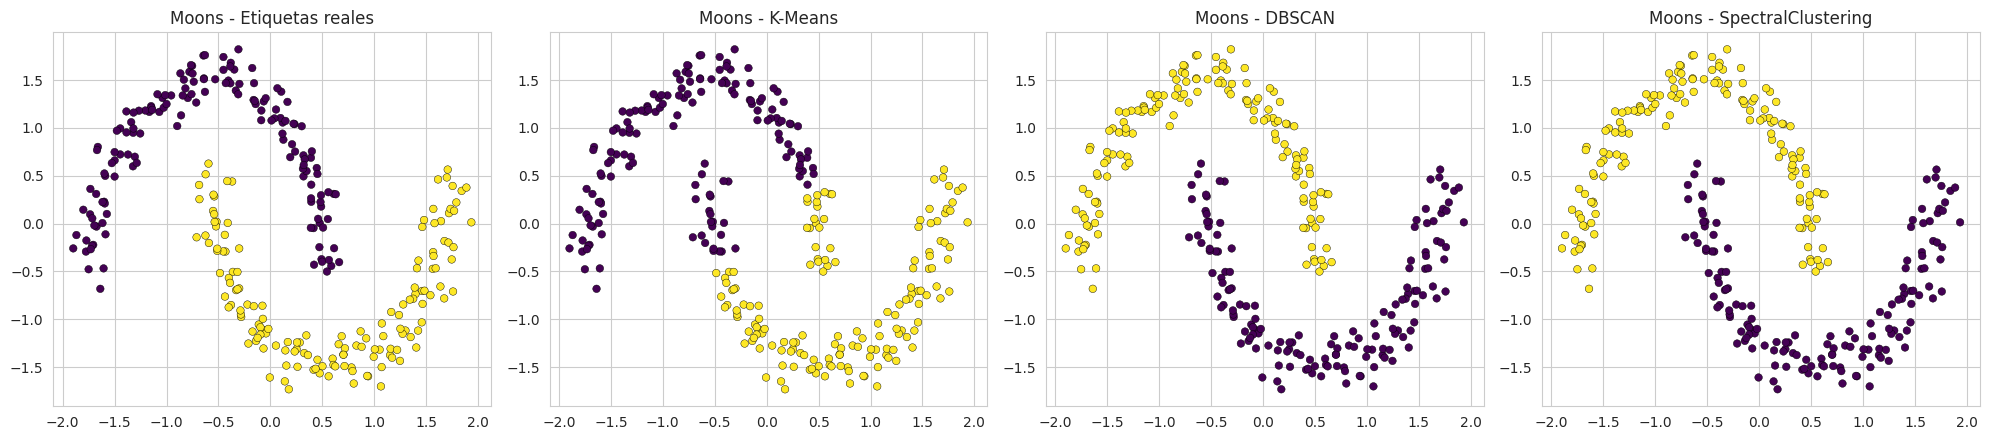

In [ ]:
models_moons = {
    "K-Means": labels_kmeans_moons,
    "DBSCAN": labels_dbscan_moons,
    "SpectralClustering": labels_spectral_moons
}
plot_all_models(X_moons_scaled, y_moons, models_moons, "Moons")

## 4. Caso: Dataset Circles

`make_circles` genera dos círculos concéntricos. Junto con Moons, es uno de los ejemplos más usados para mostrar que K-Means (basado en distancia a un centroide) falla cuando los clusters comparten aproximadamente el mismo centro pero distinto radio. Ya tiene 2 dimensiones, no se necesita PCA para graficar.

In [ ]:
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=RANDOM_STATE)

scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

print("Forma de X:", X_circles_scaled.shape)
print("Distribucion de clases:", pd.Series(y_circles).value_counts().sort_index().to_dict())

Forma de X: (300, 2)
Distribucion de clases: {0: 150, 1: 150}


### 4.1 Modelo K-Means (Circles)

K-Means es un algoritmo **basado en centroides**: asigna cada punto al centroide más cercano (distancia euclidiana) y recalcula los centroides iterativamente. Sus fronteras de decisión son hiperplanos, por lo que asume clusters **convexos**. Su hiperparámetro más crítico es `n_clusters`; aquí usamos `n_clusters=2` (conocido por el ground truth) y lo confirmamos con el método del codo.

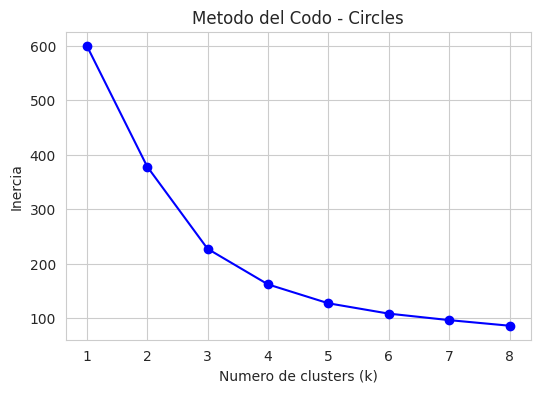

In [ ]:
_ = elbow_method(X_circles_scaled, max_k=8, title="Circles")

In [ ]:
kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels_kmeans_circles = kmeans_circles.fit_predict(X_circles_scaled)

metrics_kmeans_circles = compute_metrics_single(X_circles_scaled, y_circles, labels_kmeans_circles, "K-Means")
metrics_kmeans_circles

,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin,Clusters_encontrados,Puntos_ruido
0,K-Means,-0.0033,0.0,0.3532,1.1752,2,0


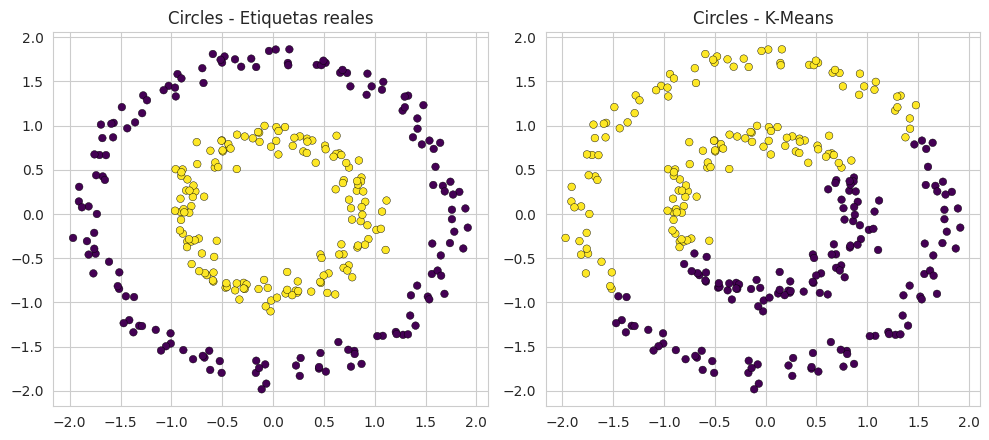

In [ ]:
plot_two_panel(X_circles_scaled, y_circles, labels_kmeans_circles, "K-Means", "Circles")

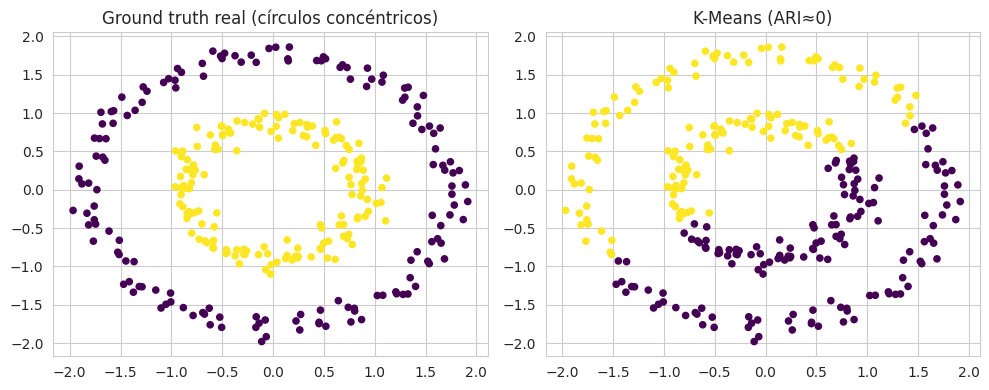

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].scatter(X_circles_scaled[:, 0], X_circles_scaled[:, 1], c=y_circles, cmap="viridis", s=20)
axs[0].set_title("Ground truth real (círculos concéntricos)")
axs[1].scatter(X_circles_scaled[:, 0], X_circles_scaled[:, 1], c=labels_kmeans_circles, cmap="viridis", s=20)
axs[1].set_title("K-Means (ARI≈0)")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score, v_measure_score

resultados_circles = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_circles_scaled)
    sil = silhouette_score(X_circles_scaled, labels)
    db = davies_bouldin_score(X_circles_scaled, labels)
    ari = adjusted_rand_score(y_circles, labels)
    vm = v_measure_score(y_circles, labels)
    resultados_circles.append({"n_clusters": k, "Silhouette": sil, "Davies-Bouldin": db, "ARI": ari, "V-Measure": vm})

df_circles_busqueda = pd.DataFrame(resultados_circles)
print(df_circles_busqueda)

mejor_silhouette = df_circles_busqueda.loc[df_circles_busqueda["Silhouette"].idxmax()]
mejor_db = df_circles_busqueda.loc[df_circles_busqueda["Davies-Bouldin"].idxmin()]
mejor_ari = df_circles_busqueda.loc[df_circles_busqueda["ARI"].idxmax()]

print(f"\nMejor según Silhouette (sin ground truth): n_clusters={mejor_silhouette['n_clusters']}")
print(f"Mejor según Davies-Bouldin (sin ground truth): n_clusters={mejor_db['n_clusters']}")
print(f"Mejor según ARI (con ground truth): n_clusters={mejor_ari['n_clusters']}")

   n_clusters  Silhouette  Davies-Bouldin       ARI  V-Measure
0           2    0.353230        1.175177 -0.003311   0.000032
1           3    0.392267        0.827406 -0.004341   0.000109
2           4    0.375121        0.810035 -0.004460   0.000549
3           5    0.356711        0.845250 -0.004709   0.000716
4           6    0.329386        0.918439 -0.004622   0.001186
5           7    0.305919        0.988174 -0.002586   0.004343
6           8    0.344087        0.897022  0.057551   0.143451

Mejor según Silhouette (sin ground truth): n_clusters=3.0
Mejor según Davies-Bouldin (sin ground truth): n_clusters=4.0
Mejor según ARI (con ground truth): n_clusters=8.0


### 4.2 Modelo DBSCAN (Circles)

DBSCAN es un algoritmo **basado en densidad**: agrupa puntos que están suficientemente cerca entre sí (radio `eps`) y que tienen al menos `min_samples` vecinos; los puntos que no cumplen esto se marcan como ruido (etiqueta `-1`). No necesita que indiquemos el número de clusters de antemano. Usamos la gráfica de k-distancias para elegir `eps`.

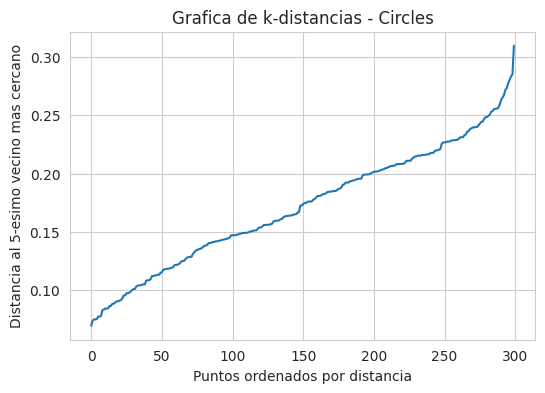

In [ ]:
_ = k_distance_plot(X_circles_scaled, k=5, title="Circles")

In [ ]:
EPS_CIRCLES = 0.35
MIN_SAMPLES_CIRCLES = 5

dbscan_circles = DBSCAN(eps=EPS_CIRCLES, min_samples=MIN_SAMPLES_CIRCLES)
labels_dbscan_circles = dbscan_circles.fit_predict(X_circles_scaled)

metrics_dbscan_circles = compute_metrics_single(X_circles_scaled, y_circles, labels_dbscan_circles, "DBSCAN")
metrics_dbscan_circles

,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin,Clusters_encontrados,Puntos_ruido
0,DBSCAN,1.0,1.0,0.1098,163.2696,2,0


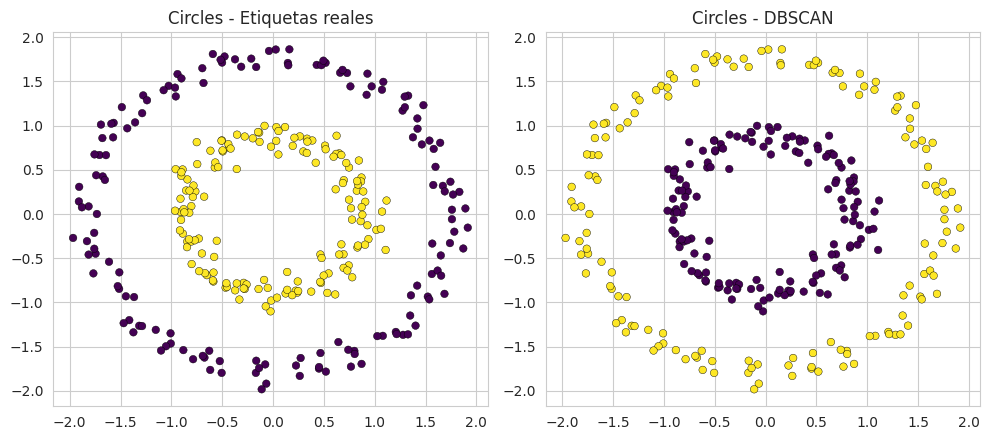

In [ ]:
plot_two_panel(X_circles_scaled, y_circles, labels_dbscan_circles, "DBSCAN", "Circles")

### 4.3 Modelo Spectral Clustering (Circles)

Spectral Clustering construye un **grafo de similitud** entre los puntos y agrupa usando los autovectores del Laplaciano de ese grafo, lo que le permite capturar estructuras no convexas. Igual que K-Means, necesita `n_clusters` como hiperparámetro (también lo tomamos del ground truth: `n_clusters=2`), además de `affinity` (aquí `'nearest_neighbors'`).

In [ ]:
spectral_circles = SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                                    n_neighbors=10, random_state=RANDOM_STATE)
labels_spectral_circles = spectral_circles.fit_predict(X_circles_scaled)

metrics_spectral_circles = compute_metrics_single(X_circles_scaled, y_circles, labels_spectral_circles, "SpectralClustering")
metrics_spectral_circles

,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin,Clusters_encontrados,Puntos_ruido
0,SpectralClustering,1.0,1.0,0.1098,163.2696,2,0


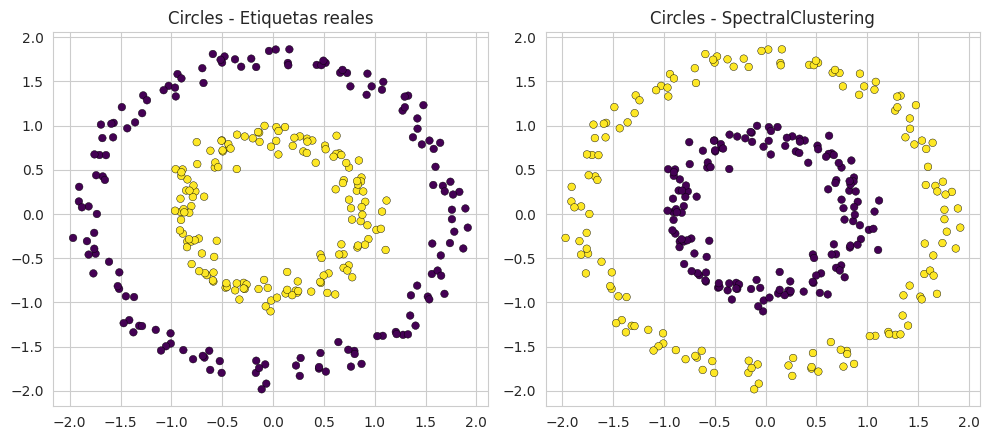

In [ ]:
plot_two_panel(X_circles_scaled, y_circles, labels_spectral_circles, "SpectralClustering", "Circles")

### 4.4 Comparación de los 3 modelos en Circles

In [ ]:
comparacion_circles = pd.concat(
    [metrics_kmeans_circles, metrics_dbscan_circles, metrics_spectral_circles],
    ignore_index=True
)
comparacion_circles

,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin,Clusters_encontrados,Puntos_ruido
0,K-Means,-0.0033,0.0,0.3532,1.1752,2,0
1,DBSCAN,1.0000,1.0,0.1098,163.2696,2,0
2,SpectralClustering,1.0000,1.0,0.1098,163.2696,2,0


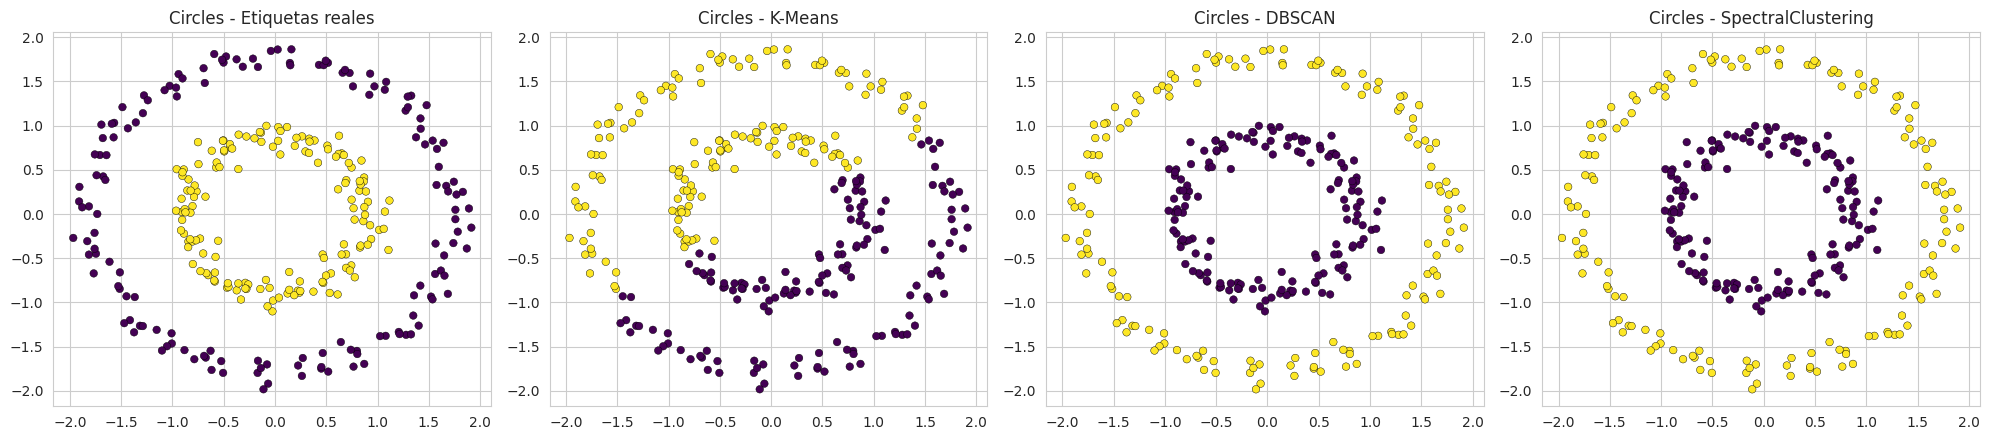

In [ ]:
models_circles = {
    "K-Means": labels_kmeans_circles,
    "DBSCAN": labels_dbscan_circles,
    "SpectralClustering": labels_spectral_circles
}
plot_all_models(X_circles_scaled, y_circles, models_circles, "Circles")

## 5. Resumen comparativo global: 3 modelos × 3 datasets

In [ ]:
resumen = pd.concat([
    metrics_kmeans_iris.assign(Dataset="Iris"),
    metrics_dbscan_iris.assign(Dataset="Iris"),
    metrics_spectral_iris.assign(Dataset="Iris"),
    metrics_kmeans_moons.assign(Dataset="Moons"),
    metrics_dbscan_moons.assign(Dataset="Moons"),
    metrics_spectral_moons.assign(Dataset="Moons"),
    metrics_kmeans_circles.assign(Dataset="Circles"),
    metrics_dbscan_circles.assign(Dataset="Circles"),
    metrics_spectral_circles.assign(Dataset="Circles"),
], ignore_index=True)

resumen = resumen[["Dataset", "Modelo", "ARI", "V-Measure", "Silhouette",
                    "Davies-Bouldin", "Clusters_encontrados", "Puntos_ruido"]]
resumen

,Dataset,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin,Clusters_encontrados,Puntos_ruido
0,Iris,K-Means,0.6201,0.6595,0.4599,0.8336,3,0
1,Iris,DBSCAN,0.5518,0.6900,0.5979,0.5688,2,4
2,Iris,SpectralClustering,0.6465,0.6838,0.4593,0.8224,3,0
3,Moons,K-Means,0.4790,0.3819,0.4945,0.8057,2,0
4,Moons,DBSCAN,1.0000,1.0000,0.3824,1.0234,2,0
5,Moons,SpectralClustering,1.0000,1.0000,0.3824,1.0234,2,0
6,Circles,K-Means,-0.0033,0.0000,0.3532,1.1752,2,0
7,Circles,DBSCAN,1.0000,1.0000,0.1098,163.2696,2,0
8,Circles,SpectralClustering,1.0000,1.0000,0.1098,163.2696,2,0


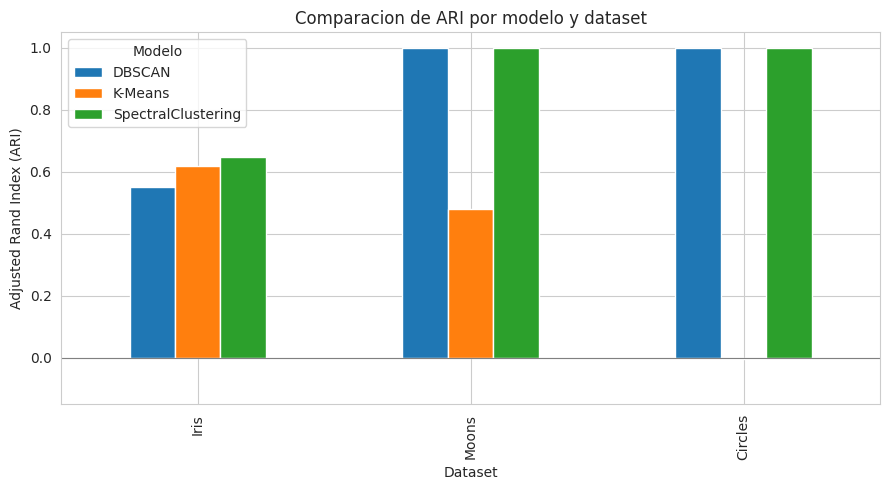

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
pivot_ari = resumen.pivot(index="Dataset", columns="Modelo", values="ARI")
pivot_ari = pivot_ari.loc[["Iris", "Moons", "Circles"]]
pivot_ari.plot(kind="bar", ax=ax)
ax.set_ylabel("Adjusted Rand Index (ARI)")
ax.set_title("Comparacion de ARI por modelo y dataset")
ax.set_ylim(-0.15, 1.05)
ax.axhline(0, color="gray", linewidth=0.8)
ax.legend(title="Modelo")
plt.tight_layout()
plt.savefig("comparacion_ari.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Naturaleza lineal / no lineal e hiperparámetros críticos por modelo

Responde a la indicación 1.4: para **cada modelo** se determina si es de naturaleza lineal o no lineal, y cuáles son sus hiperparámetros críticos para un entrenamiento exitoso.

### K-Means — Modelo LINEAL
**Por qué es lineal:** asigna cada punto al centroide más cercano (distancia euclidiana); sus fronteras de decisión son hiperplanos (diagrama de Voronoi), por lo que solo separa bien clusters **convexos** y aproximadamente esféricos. Funcionó razonablemente en Iris pero **falló en Moons y Circles** (clusters no convexos).

**Hiperparámetros críticos:**
- `n_clusters` (k): si no se conoce, se estima con el método del codo — aunque este método asume forma convexa y es poco confiable en datos no lineales (visto en Moons/Circles).
- `init` / `n_init`: una mala inicialización de centroides puede converger a un óptimo local pobre.
- `max_iter`: número máximo de iteraciones para converger.

### DBSCAN — Modelo NO LINEAL
**Por qué es no lineal:** no asume ninguna forma geométrica; agrupa según la **densidad** local, capturando formas arbitrarias (lunas, anillos) y marcando outliers como ruido (`-1`).

**Hiperparámetros críticos:**
- `eps`: radio de vecindad; muy pequeño genera ruido excesivo, muy grande fusiona clusters distintos. Se elige con la gráfica de k-distancias.
- `min_samples`: mínimo de puntos para considerar una región "densa"; afecta cuántos puntos se marcan como ruido.
- La métrica de distancia usada (por defecto euclidiana).

### Spectral Clustering — Modelo NO LINEAL
**Por qué es no lineal:** construye un grafo de similitud y usa los autovectores del Laplaciano para proyectar los datos a un espacio donde sí son linealmente separables, capturando estructuras no convexas (ARI perfecto en Moons y Circles).

**Hiperparámetros críticos:**
- `n_clusters`: debe conocerse o estimarse, igual que en K-Means.
- `affinity`: cómo se construye el grafo (`'nearest_neighbors'`, `'rbf'`, etc.).
- `n_neighbors` (si `affinity='nearest_neighbors'`) o `gamma` (si `affinity='rbf'`): controlan qué tan "local" es la similitud; un mal ajuste deja el grafo mal conectado o sobre-conectado.

| Modelo | Naturaleza | Hiperparámetros críticos |
|---|---|---|
| **K-Means** | Lineal (fronteras tipo Voronoi / hiperplanos) | `n_clusters`, `init`, `n_init`, `max_iter` |
| **DBSCAN** | No lineal (basado en densidad) | `eps`, `min_samples`, métrica de distancia |
| **Spectral Clustering** | No lineal (basado en grafo / espectro del Laplaciano) | `n_clusters`, `affinity`, `n_neighbors` o `gamma` |